In [1]:
import numpy as np
import pandas as pd
import os
import scipy.io as sio
import matplotlib
import matplotlib.pyplot as plt
from numpy.matlib import repmat
from sklearn.preprocessing import normalize
from PIL import Image

In [2]:
print(os.getcwd())

/Users/roninsuzuki/Desktop/COGS118B-FinalProject


Left data shape: (100, 1024, 1024)
Forward data shape: (2, 1024, 1024)
Right data shape: (100, 1024, 1024)
Combined data shape: (202, 1024, 1024)


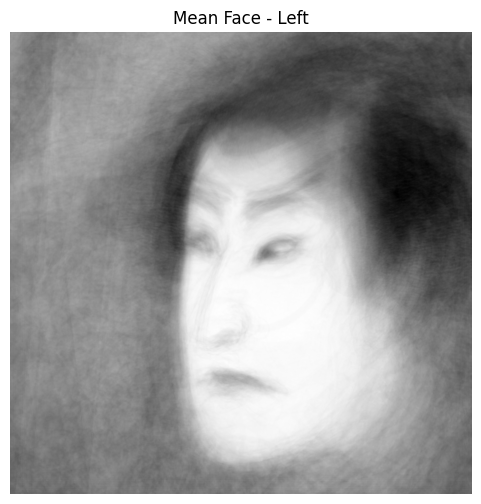

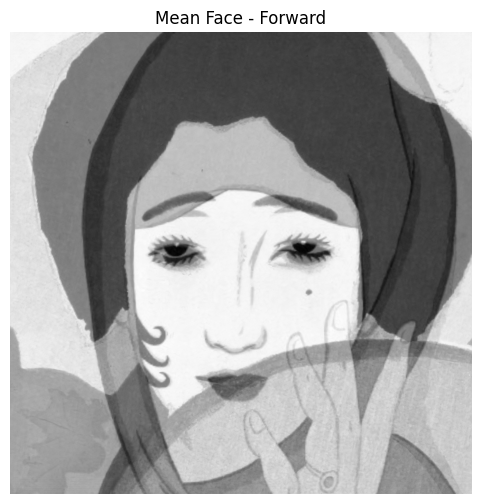

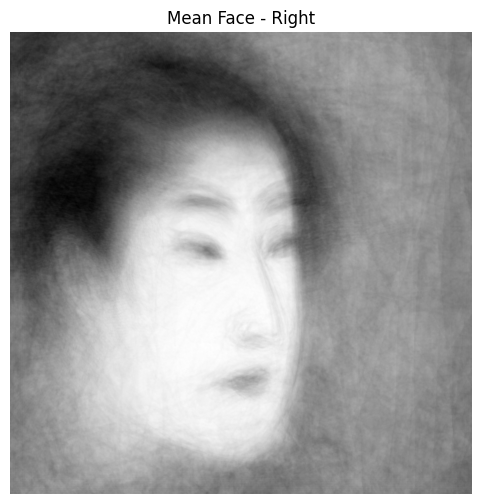

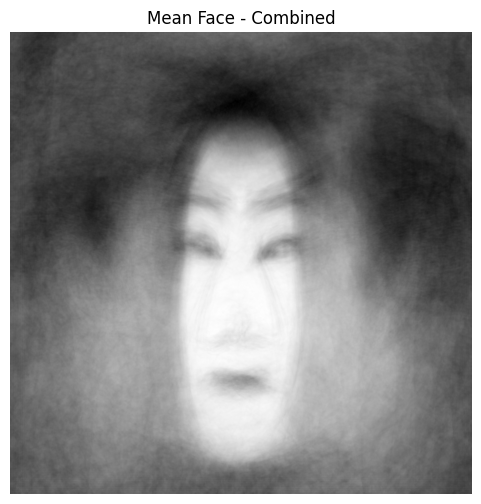

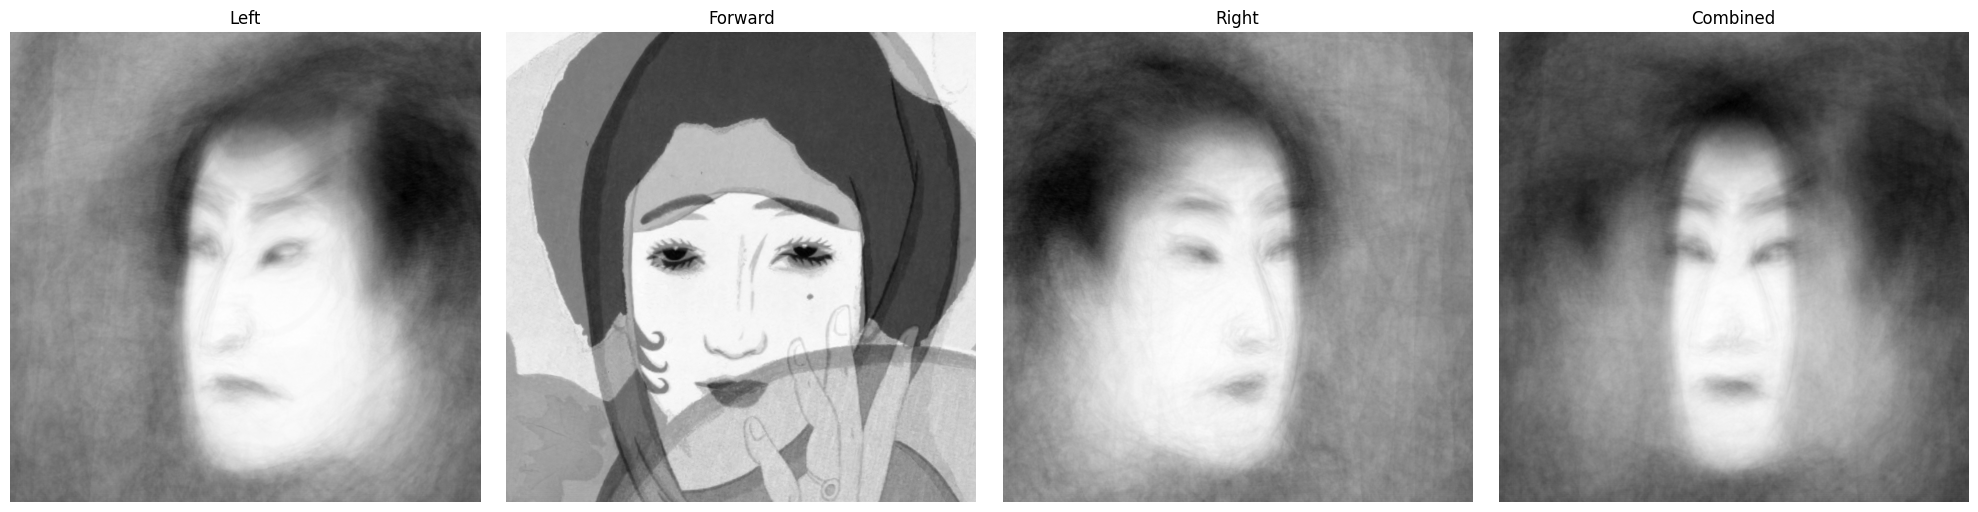

Left flat data shape: (100, 1048576)
Forward flat data shape: (2, 1048576)
Right flat data shape: (100, 1048576)
Combined flat data shape: (202, 1048576)


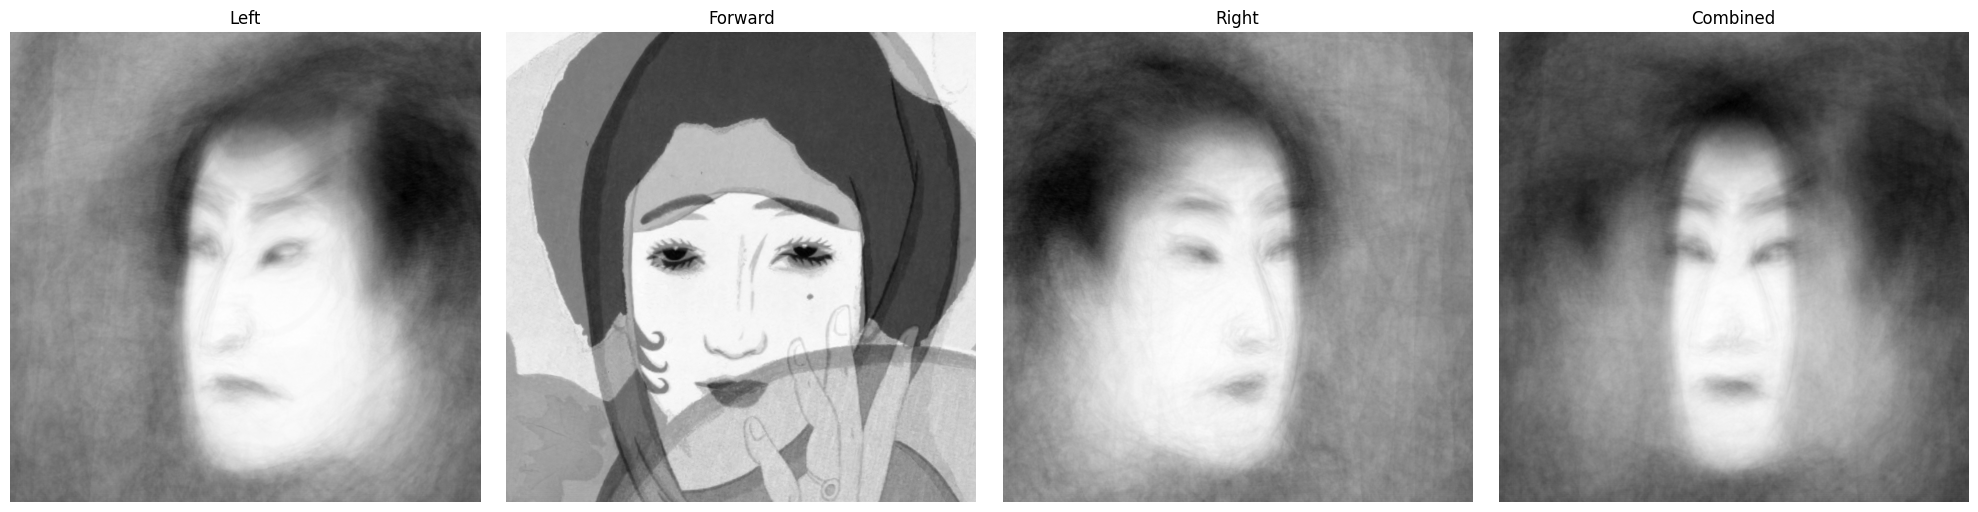

In [3]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

class FaceAnalyzer:
    def __init__(self):
        self.folder_paths = {
            'Left': "/Users/roninsuzuki/Desktop/COGS118B-FinalProject/data_L",
            'Forward': "/Users/roninsuzuki/Desktop/COGS118B-FinalProject/data_F",
            'Right': "/Users/roninsuzuki/Desktop/COGS118B-FinalProject/data_R"
        }
        self.faces = {}
        self.faces_flat = {}
        self.meanfaces = {}
        self.meanfaces_flat = {}
        
    def load_images(self, folder_key, flatten=False):
        """Load images from specified folder"""
        folder_path = self.folder_paths[folder_key]
        data = []
        
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            if os.path.isdir(img_path):
                continue
            if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            
            img = Image.open(img_path).convert("L")
            
            if flatten:
                arr = np.array(img).flatten(order="C")
                data.append(arr)
            else:
                data.append(np.array(img))
        
        return np.array(data)
    
    def load_all_folders(self, flatten=False):
        """Load images from all three folders"""
        for folder_key in self.folder_paths.keys():
            if flatten:
                self.faces_flat[folder_key] = self.load_images(folder_key, flatten=True)
                print(f"{folder_key} flat data shape: {self.faces_flat[folder_key].shape}")
            else:
                self.faces[folder_key] = self.load_images(folder_key, flatten=False)
                print(f"{folder_key} data shape: {self.faces[folder_key].shape}")
    
    def calculate_meanfaces(self, flatten=False):
        """Calculate mean face for each folder"""
        if flatten:
            for folder_key in self.folder_paths.keys():
                if folder_key in self.faces_flat:
                    self.meanfaces_flat[folder_key] = np.mean(self.faces_flat[folder_key], axis=0, keepdims=True)
        else:
            for folder_key in self.folder_paths.keys():
                if folder_key in self.faces:
                    self.meanfaces[folder_key] = np.mean(self.faces[folder_key], axis=0)
    
    def calculate_combined_meanface(self, flatten=False):
        """Calculate mean face across all folders"""
        if flatten:
            all_faces = np.vstack([self.faces_flat[key] for key in self.folder_paths.keys() if key in self.faces_flat])
            self.meanfaces_flat['Combined'] = np.mean(all_faces, axis=0, keepdims=True)
            print(f"Combined flat data shape: {all_faces.shape}")
        else:
            all_faces = np.vstack([self.faces[key] for key in self.folder_paths.keys() if key in self.faces])
            self.meanfaces['Combined'] = np.mean(all_faces, axis=0)
            print(f"Combined data shape: {all_faces.shape}")
    
    def view_meanface(self, folder_key, flatten=False):
        """Display mean face for specified folder"""
        if flatten:
            if folder_key not in self.meanfaces_flat:
                print(f"No mean face calculated for {folder_key}")
                return
            
            img_shape = self.faces_flat[list(self.faces_flat.keys())[0]].shape[1]
            side_length = int(np.sqrt(img_shape))
            meanface_reshaped = self.meanfaces_flat[folder_key].reshape(side_length, side_length)
            
            plt.figure(figsize=(6, 6))
            plt.imshow(meanface_reshaped, cmap='gray')
            plt.title(f'Mean Face - {folder_key} (Flat)')
            plt.axis('off')
            plt.show()
        else:
            if folder_key not in self.meanfaces:
                print(f"No mean face calculated for {folder_key}")
                return
            
            plt.figure(figsize=(6, 6))
            plt.imshow(self.meanfaces[folder_key], cmap='gray')
            plt.title(f'Mean Face - {folder_key}')
            plt.axis('off')
            plt.show()
    
    def view_all_meanfaces(self, flatten=False):
        """Display all mean faces in a grid"""
        keys = list(self.folder_paths.keys()) + ['Combined']
        
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        for idx, key in enumerate(keys):
            if flatten:
                if key not in self.meanfaces_flat:
                    continue
                img_shape = self.faces_flat[list(self.faces_flat.keys())[0]].shape[1]
                side_length = int(np.sqrt(img_shape))
                meanface_reshaped = self.meanfaces_flat[key].reshape(side_length, side_length)
                axes[idx].imshow(meanface_reshaped, cmap='gray')
            else:
                if key not in self.meanfaces:
                    continue
                axes[idx].imshow(self.meanfaces[key], cmap='gray')
            
            axes[idx].set_title(f'{key}')
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def normc(self, Mat):
        """Normalize columns of matrix to length 1"""
        return normalize(Mat, norm='l2', axis=0)
    
    def view_face(self, folder_key, n):
        """View the nth face from specified folder"""
        if folder_key not in self.faces:
            print(f"No faces loaded for {folder_key}")
            return
        
        plt.figure(figsize=(6, 6))
        plt.imshow(self.faces[folder_key][n], cmap='gray')
        plt.title(f'{folder_key} - Face {n}')
        plt.axis('off')
        plt.show()


# Usage:
# Initialize analyzer (no path needed now - paths are hardcoded)
analyzer = FaceAnalyzer()

# Load all images (non-flat)
analyzer.load_all_folders(flatten=False)

# Calculate mean faces for each folder
analyzer.calculate_meanfaces(flatten=False)

# Calculate combined mean face
analyzer.calculate_combined_meanface(flatten=False)

# View individual mean faces
analyzer.view_meanface('Left')
analyzer.view_meanface('Forward')
analyzer.view_meanface('Right')
analyzer.view_meanface('Combined')

# Or view all at once
analyzer.view_all_meanfaces(flatten=False)

# For flattened version:
analyzer.load_all_folders(flatten=True)
analyzer.calculate_meanfaces(flatten=True)
analyzer.calculate_combined_meanface(flatten=True)
analyzer.view_all_meanfaces(flatten=True)